# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together. This is from 22-23 season, feel free to update to 2023-24 season if you want.
# Data Sources:

https://www.basketball-reference.com/leagues/NBA_2024_totals.html # reference for performance data
https://www.basketball-reference.com/contracts/players.html # reference for salary data


Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import plotly.express as px
#import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

NBA_salary = pd.read_csv("/workspaces/DS-3021/data/nba_salaries_22.csv")
NBA_preformance = pd.read_csv("data/NBA_Perf_22.csv", encoding = "latin")

In [24]:
#Drop variables that will not be needed or are duplicates
NBA_combined = pd.merge(NBA_salary, NBA_preformance, on="Player")
#making salary into a float and removing the $
NBA_combined["Salary"] = (NBA_combined["Salary"].replace(r'[\$,]', '', regex=True).astype(float))
#Dropping variables with low correlation to salary, and variables that can't be used (position, team)
print(NBA_combined.corr(numeric_only=True)["Salary"].sort_values(ascending=False))
#dropping most percentages and variables that have similar variables (corr under .5)
dropped_columns = ["Tm",'Pos', '2P%','eFG%','FG%','3P%','ORB','FT%','G','BLK', 
                   'Age','PF','STL','TRB', '2PA', '3PA', 'FTA',]
NBA_combined = NBA_combined.drop(columns=dropped_columns)


#creating new data frame with only variables used for clustering 
NBA_clustering = NBA_combined.drop(columns=["Player", 'Salary'])


#remove the rows with missing values, or are duplicates  
NBA_clustering = NBA_clustering.dropna()
#need to standardize the data
numeric_columns = NBA_clustering.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()
NBA_clustering_scaled = scaler.fit_transform(NBA_clustering[numeric_columns])
NBA_clustering_scaled = pd.DataFrame(NBA_clustering_scaled, columns=numeric_columns)



Salary    1.000000
PTS       0.784472
FG        0.770245
FGA       0.758676
2PA       0.713573
FT        0.707581
FTA       0.699041
2P        0.693522
TOV       0.682251
MP        0.676218
AST       0.615907
DRB       0.586631
GS        0.574226
3PA       0.522614
3P        0.503521
TRB       0.495766
STL       0.469915
PF        0.398204
Age       0.322335
BLK       0.272589
G         0.230218
FT%       0.164702
ORB       0.150938
3P%       0.056778
FG%       0.039342
eFG%      0.034636
2P%      -0.019732
Name: Salary, dtype: float64


In [25]:
#Run the clustering algo with your best guess for K

kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(NBA_clustering_scaled)

KMeans(n_clusters=3, random_state=1)

In [26]:
#View the results
print(kmeans.cluster_centers_)
print(kmeans.labels_)
print(kmeans.inertia_)

[[ 0.16109505  0.32928638  0.07394198  0.07710269  0.18715909 -0.0030761
  -0.09701428  0.19778901 -0.04441359 -0.0623352   0.05842307]
 [-0.77185161 -0.98609738 -0.86444165 -0.86328646 -0.66490011 -0.72888522
  -0.64083088 -0.71729103 -0.63612933 -0.69847604 -0.8604577 ]
 [ 1.2024865   1.29770565  1.55245397  1.54408182  0.94238021  1.43540736
   1.44421048  1.02459004  1.3333634   1.49026082  1.57462392]]
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2
 2 2 2 0 2 2 2 2 0 2 0 0 2 2 0 2 2 2 2 0 0 2 2 0 0 0 0 2 2 0 0 0 2 2 0 0 0
 2 2 2 2 0 0 0 2 2 2 0 0 0 2 0 2 2 2 2 2 0 0 0 0 2 0 0 0 0 2 2 2 0 0 0 0 2
 0 0 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 2 0 0 2 0 0 2 2 0 0 0 0 0 1
 0 0 0 1 0 0 0 1 0 0 2 0 1 0 0 0 0 0 0 2 0 0 0 0 0 1 2 0 0 0 2 0 2 1 0 1 0
 0 1 1 1 1 1 1 0 1 0 2 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0
 0 1 0 2 0 0 0 0 2 1 1 1 0 0 2 0 1 0 1 1 1 1 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 1 2 2 2 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1

/tmp/ipykernel_686/714835476.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NBA_visualization["Cluster"] = kmeans.labels_.astype(str)


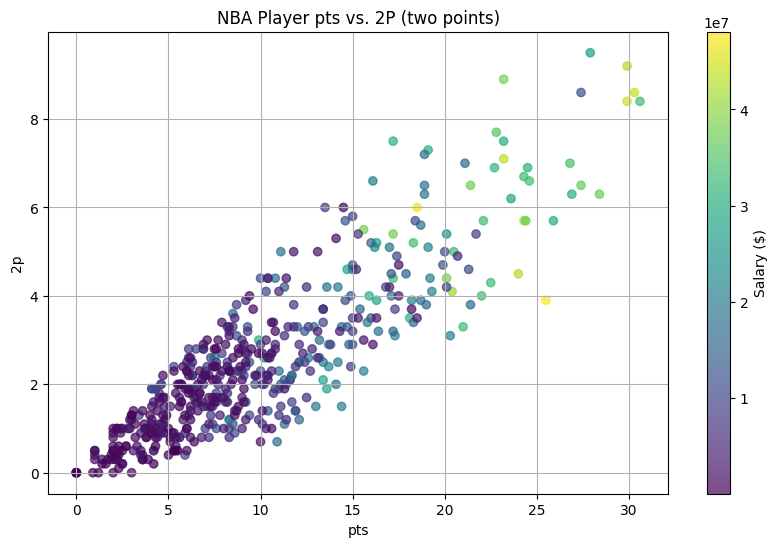

In [27]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters
NBA_combined.corr(numeric_only=True)["Salary"].sort_values(ascending=False)

#Create a new data frame with the variables that will be used for visualization
NBA_visualization = NBA_clustering_scaled[["PTS", "2P", "FG"]]
NBA_visualization["Cluster"] = kmeans.labels_.astype(str)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(NBA_combined["PTS"],NBA_combined["2P"],c=NBA_combined["Salary"],cmap="viridis",alpha=0.7)
#adding color to salary
plt.colorbar(scatter, label="Salary ($)")
# Label the axes and title
plt.xlabel("pts")
plt.ylabel("2p")
plt.title("NBA Player pts vs. 2P (two points)")
plt.grid(True)
plt.show()

In [28]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores

#Explained Variance - this is a measure of how much of the total variance in the data is explained by the clustering
total_sum_squares = np.sum((NBA_clustering_scaled - np.mean(NBA_clustering_scaled))**2)
total = np.sum(total_sum_squares)
between_SSE = (total-kmeans.inertia_)
#The explained variance ranges from 0 to 1, with higher values indicating better clustering
#calculated as the ratio of the between-cluster sum of squares to the total sum of squares
Var_explained = between_SSE/total
#relatively high variance explained
print(Var_explained)

#Silhouette Score - this is a measure of how well the clusters are separated
#The silhouette score ranges from -1 to 1, with higher values indicating better clustering
from sklearn.metrics import silhouette_score
#the sil
silhouette_scores = []
for k in range(2, 11):
    kmeans_obj = KMeans(n_clusters=k, algorithm="elkan", random_state=1).fit(NBA_clustering_scaled)
    silhouette_scores.append(silhouette_score(NBA_clustering_scaled, kmeans_obj.labels_))



0.6293660541058237


/home/vscode/.local/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [29]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

#Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=1).fit(NBA_clustering_scaled)
    wcss.append(kmeans.inertia_)

#the optimal number of clusters is where the elbow plot starts to level off or where the elbow is 
#in this case it occurs at 2 clusters, and there is a slight one at 4 clusters

#Silhouette Coefficient
best_nc = silhouette_scores.index(max(silhouette_scores))+2
# best_nc is the number of clusters that gives the best silhouette score
print(best_nc)
#The silhouette score is highest at 2 clusters, but the elbow method suggests that 2 or 4 clusters is the best numbers of clusters

2


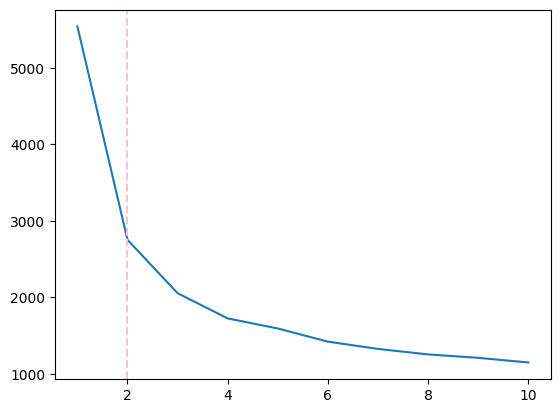

In [30]:
#Visualize the results of the elbow method
#the best number of clusters is 2 and 4
plt.plot(range(1, 11), wcss)
plt.axvline(x=2, color = 'pink',linestyle='--')
plt.show()

In [31]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results

#In this case we will use 2 clusters
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(NBA_visualization)


KMeans(n_clusters=2, random_state=1)

In [32]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores
#Evaluate the quality of the clustering using total variance explained and silhouette scores

#Explained Variance - this is a measure of how much of the total variance in the data is explained by the clustering
total_sum_squares = np.sum((NBA_clustering_scaled - np.mean(NBA_clustering_scaled))**2)
total = np.sum(total_sum_squares)
between_SSE = (total-kmeans.inertia_)
#The explained variance ranges from 0 to 1, with higher values indicating better clustering
#calculated as the ratio of the between-cluster sum of squares to the total sum of squares
Var_explained = between_SSE/total
#relatively high variance explained
print(Var_explained)

#Silhouette Score - this is a measure of how well the clusters are separated
#The silhouette score ranges from -1 to 1, with higher values indicating better clustering
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans_obj = KMeans(n_clusters=k, algorithm="elkan", random_state=1).fit(NBA_clustering_scaled)
    silhouette_scores.append(silhouette_score(NBA_clustering_scaled, kmeans_obj.labels_))



0.874716669804371


/home/vscode/.local/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [33]:
#Use the model to select players for Mr. Rooney to consider
NBA_combined["Cluster"] = kmeans.labels_

cluster_summary = NBA_combined.groupby("Cluster")[["Salary", "PTS", "AST", "FG"]].mean()
print(cluster_summary)

target_cluster = 1
recommendations = NBA_combined[NBA_combined["Cluster"] == target_cluster]
recommendations = recommendations[recommendations["Salary"] < 5000000]
recommendations = recommendations.sort_values("PTS", ascending=True)
recommendations[["Player", "Salary", "PTS", "2P", "FG"]].head(20)



               Salary        PTS       AST        FG
Cluster                                             
0        2.155543e+07  19.310092  4.536697  7.011927
1        5.872463e+06   7.269114  1.570633  2.691139


,Player,Salary,PTS,2P,FG
279,Danuel House Jr.,4105000.0,0.0,0.0,0.0
358,Luke Kornet,2133278.0,0.0,0.0,0.0
388,Wenyen Gabriel,1878720.0,0.0,0.0,0.0
498,Didi Louzada,268032.0,0.0,0.0,0.0
489,Juwan Morgan,576230.0,0.0,0.0,0.0
491,Malik Fitts,555217.0,0.9,0.0,0.3
325,Bruno Fernando,2717391.0,1.0,0.3,0.4
319,Kai Jones,2909040.0,1.0,0.4,0.4
447,Tyrell Terry,1782621.0,1.0,0.5,0.5
361,Jaden Springer,2125200.0,1.0,0.5,0.5


#Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.